In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision

# -------------------------------
# IMPORTANT: GPU config MUST come first, before any TF operations
# -------------------------------

# 1. Enable GPU memory growth BEFORE initialization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"Memory growth setting failed: {e}")

# 2. Enable mixed precision (recommended for RTX 4060)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled: mixed_float16")

# 3. Now check GPU availability (this is safe after config)
print("Available GPUs:", gpus)

Memory growth enabled for 1 GPU(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9
Mixed precision enabled: mixed_float16
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import mixed_precision
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [4]:
emotion_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\emotion_augmented_backtranslation.csv")
violence_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\violence_augmented_backtranslation.csv")
hate_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\hate_augmented_backtranslation.csv")

In [5]:
emotion_df.shape, violence_df.shape, hate_df.shape

((431781, 2), (86648, 2), (37190, 2))

In [6]:
emotion_df['label'].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     29944
Name: count, dtype: int64

In [7]:
e_df = pd.DataFrame()
for i in range(6):
    subset = emotion_df[emotion_df['label'] == i].sample(n=4500, random_state=42)
    e_df = pd.concat([e_df, subset])

In [8]:
e_df.shape

(27000, 2)

In [9]:
emotion_df = e_df.copy()

In [10]:
emotion_df['label'].value_counts()

label
0    4500
1    4500
2    4500
3    4500
4    4500
5    4500
Name: count, dtype: int64

In [11]:
violence_df['label'].value_counts()

label
4    32648
1    18000
3    12000
0    12000
2    12000
Name: count, dtype: int64

In [12]:
v_df = pd.DataFrame()
for i in range(5):
    subset = violence_df[violence_df['label'] == i].sample(n=5400, random_state=42)
    v_df = pd.concat([v_df, subset])

In [13]:
v_df.shape

(27000, 2)

In [14]:
violence_df = v_df.copy()

In [15]:
violence_df['label'].value_counts()

label
0    5400
1    5400
2    5400
3    5400
4    5400
Name: count, dtype: int64

In [16]:
hate_df['label'].value_counts()

label
1    19190
2     9000
0     9000
Name: count, dtype: int64

In [17]:
h_df = pd.DataFrame()
for i in range(3):
    subset = hate_df[hate_df['label'] == i].sample(n=9000, random_state=42)
    h_df = pd.concat([h_df, subset])

In [18]:
h_df.shape

(27000, 2)

In [19]:
hate_df = h_df.copy()

In [20]:
hate_df['label'].value_counts()

label
0    9000
1    9000
2    9000
Name: count, dtype: int64

In [21]:
emotion_df.reset_index(drop = True, inplace = True)
violence_df.reset_index(drop = True, inplace = True)
hate_df.reset_index(drop = True, inplace = True)

In [22]:
'''
Emotions
0 : Sadness
1 : Joy
2 : Love
3 : Anger
4 : Fear
5 : Surprise

Violence
0 : Harmful_Traditional_practice
1 : Physical_violence 
2 : economic_violence
3 : emotional_violence  
4 : sexual_violence 

Hate
0 : Hate Speech
1 : Offensive Speech
2 : Neither

'''

'\nEmotions\n0 : Sadness\n1 : Joy\n2 : Love\n3 : Anger\n4 : Fear\n5 : Surprise\n\nViolence\n0 : Harmful_Traditional_practice\n1 : Physical_violence \n2 : economic_violence\n3 : emotional_violence  \n4 : sexual_violence \n\nHate\n0 : Hate Speech\n1 : Offensive Speech\n2 : Neither\n\n'

4. Stopwords Removal

In [23]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
stop_words = set(stopwords.words('english'))

In [25]:
len(stop_words)

198

In [26]:
def remove_stopwords(text):
    all_words = nltk.word_tokenize(text)
    filtered_words = [word for word in all_words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

emotion_df['text'] = emotion_df['text'].apply(remove_stopwords)
violence_df['text'] = violence_df['text'].apply(remove_stopwords)
hate_df['text'] = hate_df['text'].apply(remove_stopwords)

5. Tokenization and Padding

In [27]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([emotion_df['text'],violence_df['text'],hate_df['text']]))

In [28]:
emotion_sequences = tokenizer.texts_to_sequences(emotion_df['text'])
violence_sequences = tokenizer.texts_to_sequences(violence_df['text'])
hate_sequences = tokenizer.texts_to_sequences(hate_df['text'])

In [29]:
emotion_df['text'].iloc[2]

'feel like lost mourned moved past tears relationship'

In [30]:
emotion_sequences[2]

[1, 2, 234, 18805, 958, 465, 1735, 454]

In [31]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequences, maxlen = max_length, padding = 'post')
violence_padded = pad_sequences(violence_sequences, maxlen = max_length, padding = 'post')
hate_padded = pad_sequences(hate_sequences, maxlen = max_length, padding = 'post')

In [32]:
emotion_padded[2]

array([    1,     2,   234, 18805,   958,   465,  1735,   454,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0])

In [33]:
# labels as np array

emotion_labels = np.array(emotion_df['label'])
violence_labels = np.array(violence_df['label'])
hate_labels = np.array(hate_df['label'])

6. Model Architecture

In [34]:
# separate inputs for each dataset
emotion_input = emotion_padded
violence_input = violence_padded
hate_input = hate_padded

# multiple input layers for each task
emotion_input_layer = keras.layers.Input(shape=(max_length,), name='emotion_input')
violence_input_layer = keras.layers.Input(shape=(max_length,), name='violence_input')
hate_input_layer = keras.layers.Input(shape=(max_length,), name='hate_input')

# shared embedding layer
embedding_layer = keras.layers.Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=128
)

# apply embedding layer to each input
emotion_embedding = embedding_layer(emotion_input_layer)
violence_embedding = embedding_layer(violence_input_layer)
hate_embedding = embedding_layer(hate_input_layer)

# shared Bidirectional LSTM layer
shared_bilstm = keras.layers.Bidirectional(
    keras.layers.LSTM(64, return_sequences=True)
)

# apply shared BiLSTM to each task
emotion_lstm = shared_bilstm(emotion_embedding)
violence_lstm = shared_bilstm(violence_embedding)
hate_lstm = shared_bilstm(hate_embedding)

# shared pooling and dropout
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

emotion_features = shared_dropout(shared_pooling(emotion_lstm))
violence_features = shared_dropout(shared_pooling(violence_lstm))
hate_features = shared_dropout(shared_pooling(hate_lstm))

# output layers
emotion_output = keras.layers.Dense(6, activation='softmax', name='emotion_output')(emotion_features)
violence_output = keras.layers.Dense(5, activation='softmax', name='violence_output')(violence_features)
hate_output = keras.layers.Dense(3, activation='softmax', name='hate_output')(hate_features)

# define model
model = keras.models.Model(
    inputs=[emotion_input_layer, violence_input_layer, hate_input_layer],
    outputs=[emotion_output, violence_output, hate_output]
)

# compile
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': 'sparse_categorical_crossentropy',
        'hate_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'hate_output': 'accuracy'
    }
)


In [35]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 emotion_input (InputLayer)     [(None, 50)]         0           []                               
                                                                                                  
 violence_input (InputLayer)    [(None, 50)]         0           []                               
                                                                                                  
 hate_input (InputLayer)        [(None, 50)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 50, 128)      6169344     ['emotion_input[0][0]',          
                                                                  'violence_input[0][0]',     

In [36]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.10.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
model.fit(
    x={
        'emotion_input': emotion_input,
        'violence_input': violence_input,
        'hate_input': hate_input
    },
    y={
        'emotion_output': emotion_labels,
        'violence_output': violence_labels,
        'hate_output': hate_labels
    },
    epochs=10,
    batch_size=32
)

Epoch 1/10
844/844 [==============================] - 35s 27ms/step - loss: 2.0212 - emotion_output_loss: 1.2130 - violence_output_loss: 0.2365 - hate_output_loss: 0.5718 - emotion_output_accuracy: 0.5229 - violence_output_accuracy: 0.9118 - hate_output_accuracy: 0.7669
Epoch 2/10
844/844 [==============================] - 23s 27ms/step - loss: 0.7301 - emotion_output_loss: 0.4760 - violence_output_loss: 0.0258 - hate_output_loss: 0.2283 - emotion_output_accuracy: 0.8623 - violence_output_accuracy: 0.9946 - hate_output_accuracy: 0.9297
Epoch 3/10
844/844 [==============================] - 23s 27ms/step - loss: 0.4070 - emotion_output_loss: 0.2712 - violence_output_loss: 0.0118 - hate_output_loss: 0.1240 - emotion_output_accuracy: 0.9240 - violence_output_accuracy: 0.9976 - hate_output_accuracy: 0.9626
Epoch 4/10
844/844 [==============================] - 23s 27ms/step - loss: 0.2762 - emotion_output_loss: 0.1904 - violence_output_loss: 0.0065 - hate_output_loss: 0.0793 - emotion_output

7. Prediction and Evaluation

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions
prediction = model.predict({'emotion_input': emotion_input,
                           'violence_input': violence_input,
                           'hate_input': hate_input})

emotion_pred = np.argmax(prediction[0], axis=1)
violence_pred = np.argmax(prediction[1], axis=1)
hate_pred = np.argmax(prediction[2], axis=1)

# Function to calculate and print metrics
def print_metrics(true, pred, task_name):
    print(f"\n{'='*50}")
    print(f"Metrics for {task_name}")
    print(f"{'='*50}")
    
    accuracy = accuracy_score(true, pred)
    precision = precision_score(true, pred, average='weighted', zero_division=0)
    recall = recall_score(true, pred, average='weighted', zero_division=0)
    f1 = f1_score(true, pred, average='weighted', zero_division=0)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    return accuracy, precision, recall, f1

# Calculate metrics for each task
emotion_metrics = print_metrics(emotion_labels, emotion_pred, "Emotion Classification")
violence_metrics = print_metrics(violence_labels, violence_pred, "Violence Classification")
hate_metrics = print_metrics(hate_labels, hate_pred, "Hate Speech Classification")

844/844 [==============================] - 22s 24ms/step

Metrics for Emotion Classification
Accuracy:  0.9822
Precision: 0.9824
Recall:    0.9822
F1 Score:  0.9822

Metrics for Violence Classification
Accuracy:  0.9998
Precision: 0.9998
Recall:    0.9998
F1 Score:  0.9998

Metrics for Hate Speech Classification
Accuracy:  0.9964
Precision: 0.9964
Recall:    0.9964
F1 Score:  0.9964


In [39]:
# Calculate overall metrics (macro average across all tasks)
print(f"\n{'='*50}")
print(f"Overall Model Performance (Macro Average)")
print(f"{'='*50}")

overall_accuracy = np.mean([emotion_metrics[0], violence_metrics[0], hate_metrics[0]])
overall_precision = np.mean([emotion_metrics[1], violence_metrics[1], hate_metrics[1]])
overall_recall = np.mean([emotion_metrics[2], violence_metrics[2], hate_metrics[2]])
overall_f1 = np.mean([emotion_metrics[3], violence_metrics[3], hate_metrics[3]])

print(f"Overall Accuracy:  {overall_accuracy:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall:    {overall_recall:.4f}")
print(f"Overall F1 Score:  {overall_f1:.4f}")



Overall Model Performance (Macro Average)
Overall Accuracy:  0.9928
Overall Precision: 0.9929
Overall Recall:    0.9928
Overall F1 Score:  0.9928


In [40]:
#detailed classification report for each task
print(f"\n{'='*50}")
print("Detailed Classification Reports")
print(f"{'='*50}")

emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
violence_labels_text = ['sexual_violence', 'physical_violence', 'emotional_violence', 
                        'Harmful_traditional_practice', 'economic_violence']
hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

print("\nEmotion Classification Report:")
print(classification_report(emotion_labels, emotion_pred, target_names=emotion_labels_text))

print("\nViolence Classification Report:")
print(classification_report(violence_labels, violence_pred, target_names=violence_labels_text))

print("\nHate Speech Classification Report:")
print(classification_report(hate_labels, hate_pred, target_names=hate_labels_text))


Detailed Classification Reports

Emotion Classification Report:
              precision    recall  f1-score   support

     sadness       0.99      0.99      0.99      4500
         joy       1.00      0.97      0.98      4500
        love       0.98      1.00      0.99      4500
       anger       0.99      0.97      0.98      4500
        fear       0.96      0.97      0.97      4500
    surprise       0.97      0.99      0.98      4500

    accuracy                           0.98     27000
   macro avg       0.98      0.98      0.98     27000
weighted avg       0.98      0.98      0.98     27000


Violence Classification Report:
                              precision    recall  f1-score   support

             sexual_violence       1.00      1.00      1.00      5400
           physical_violence       1.00      1.00      1.00      5400
          emotional_violence       1.00      1.00      1.00      5400
Harmful_traditional_practice       1.00      1.00      1.00      5400
        

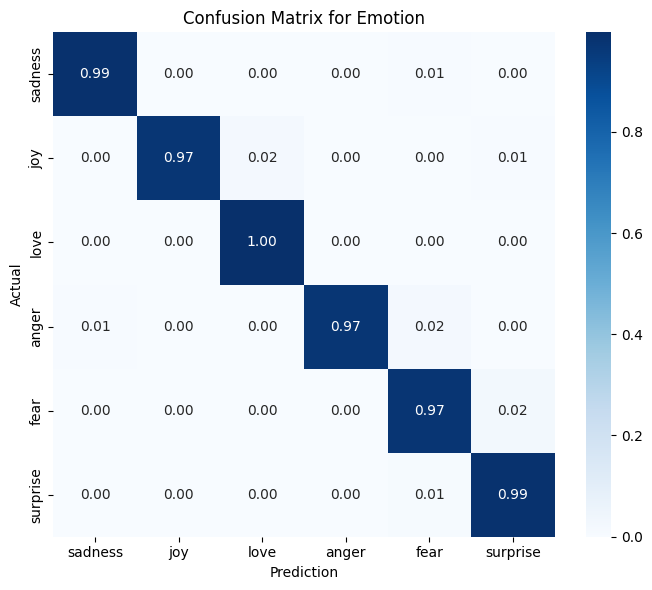

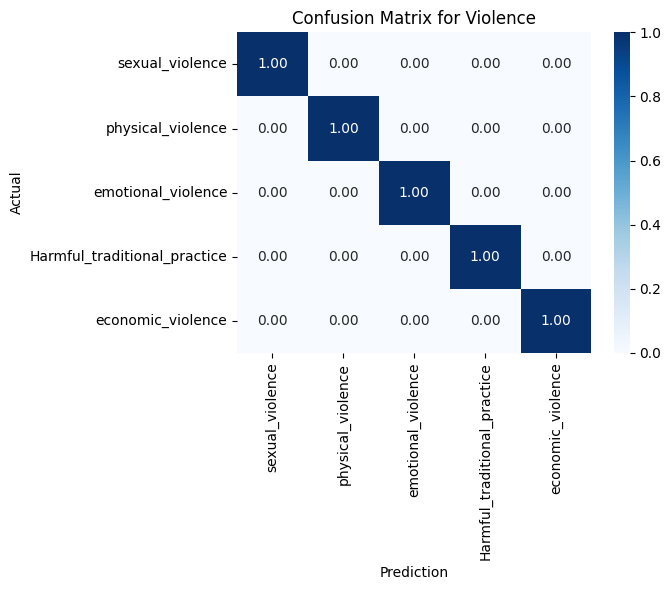

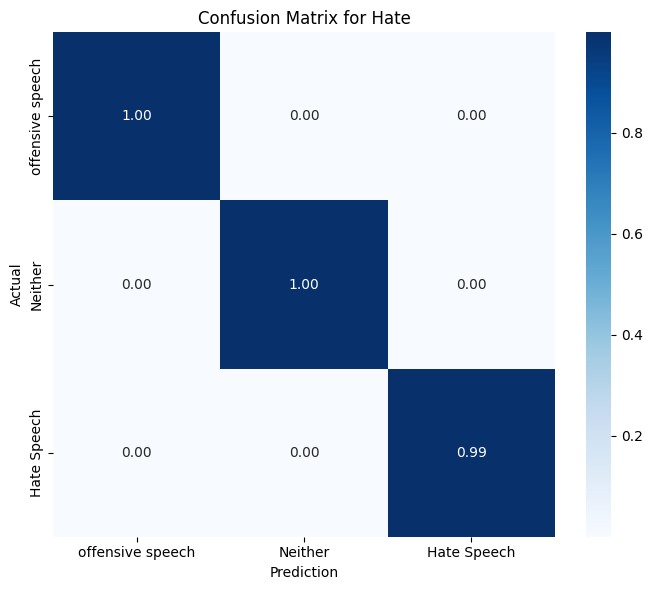

In [41]:
# Plot confusion matrices
def plot_cm(true, pred, title, labels):
    cf = confusion_matrix(true, pred, normalize='true')
    plt.figure(figsize=(7, 6))
    sns.heatmap(cf, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, fmt='.2f')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Prediction')
    plt.tight_layout()

plot_cm(emotion_labels, emotion_pred, 'Confusion Matrix for Emotion', emotion_labels_text)
plot_cm(violence_labels, violence_pred, 'Confusion Matrix for Violence', violence_labels_text)
plot_cm(hate_labels, hate_pred, 'Confusion Matrix for Hate', hate_labels_text)
plt.show()

In [42]:
'''
Emotions
0 : Sadness
1 : Joy
2 : Love
3 : Anger
4 : Fear
5 : Surprise

Violence
0 : Harmful_Traditional_practice
1 : Physical_violence 
2 : economic_violence
3 : emotional_violence  
4 : sexual_violence 

Hate
0 : Hate Speech
1 : Offensive Speech
2 : Neither

'''

'\nEmotions\n0 : Sadness\n1 : Joy\n2 : Love\n3 : Anger\n4 : Fear\n5 : Surprise\n\nViolence\n0 : Harmful_Traditional_practice\n1 : Physical_violence \n2 : economic_violence\n3 : emotional_violence  \n4 : sexual_violence \n\nHate\n0 : Hate Speech\n1 : Offensive Speech\n2 : Neither\n\n'

In [43]:
# =============================================================================
# IMPROVED SINGLE-TEXT LIME EXPLANATION WITH VALIDATION
# =============================================================================

import numpy as np
import pandas as pd
from datetime import datetime
from collections import Counter

import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from lime.lime_text import LimeTextExplainer

# -----------------------------
# NLTK setup (safe to re-run)
# -----------------------------
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

print("GPU Available:", tf.config.list_physical_devices('GPU'))


# =============================================================================
# IMPROVED LIME EXPLAINER CLASS
# =============================================================================
class ImprovedMultitaskLIMEExplainer:
    def __init__(self, model, tokenizer, max_length=50):
        self.model = model
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
        self.violence_labels = [
            'Harmful_Traditional_practice',
            'Physical_violence',
            'economic_violence',
            'emotional_violence',
            'sexual_violence'
        ]
        self.hate_labels = ['Hate Speech', 'Offensive Speech', 'Neither']

        # LIME explainers with increased samples for stability
        self.lime_emotion = LimeTextExplainer(class_names=self.emotion_labels)
        self.lime_violence = LimeTextExplainer(class_names=self.violence_labels)
        self.lime_hate = LimeTextExplainer(class_names=self.hate_labels)

    # -----------------------------
    # Preprocessing (FIXED: optional stopword removal)
    # -----------------------------
    def _clean_text(self, text, remove_stopwords=False):
        """
        IMPROVEMENT: Made stopword removal optional to avoid preprocessing mismatch
        Set remove_stopwords=True only if your model was trained with stopwords removed
        """
        tokens = nltk.word_tokenize(text.lower())
        if remove_stopwords:
            return " ".join([w for w in tokens if w not in stop_words])
        return " ".join(tokens)

    def _encode(self, text):
        cleaned = self._clean_text(text, remove_stopwords=False)
        seq = self.tokenizer.texts_to_sequences([cleaned])
        return pad_sequences(seq, maxlen=self.max_length, padding="post")

    # -----------------------------
    # Prediction helpers (LIME)
    # -----------------------------
    def _predict_all(self, texts):
        X = np.vstack([self._encode(t) for t in texts])
        return self.model.predict(
            {
                "emotion_input": X,
                "violence_input": X,
                "hate_input": X
            },
            verbose=0
        )

    def predict_emotion(self, texts):
        return self._predict_all(texts)[0]

    def predict_violence(self, texts):
        return self._predict_all(texts)[1]

    def predict_hate(self, texts):
        return self._predict_all(texts)[2]

    # -----------------------------
    # IMPROVED: Trust score with better metrics
    # -----------------------------
    def _trust_score(self, explanation, probs):
        """
        IMPROVEMENTS:
        1. Uses LIME's R² score (local model fit quality)
        2. Better concentration metric using Gini-style cumulative weights
        3. More interpretable calculation
        """
        confidence = float(np.max(probs))
        
        # LIME's local model R² score (how well it approximates the model)
        lime_r2 = explanation.score if hasattr(explanation, 'score') else 0.5
        lime_r2 = max(0, min(1, lime_r2))  # Clip to [0,1]
        
        exp = explanation.as_list()
        if not exp:
            return 0.0

        # Concentration: Are top features dominant?
        weights = np.abs([w for _, w in exp])
        sorted_weights = np.sort(weights)[::-1]
        
        # What % of total weight is in top 3 features?
        top_3_weight = sum(sorted_weights[:min(3, len(sorted_weights))])
        total_weight = sum(sorted_weights) + 1e-8
        concentration = top_3_weight / total_weight
        
        # Combined trust score with emphasis on LIME fit quality
        trust = 0.4 * confidence + 0.4 * lime_r2 + 0.2 * concentration
        return float(np.clip(trust, 0, 1))

    # -----------------------------
    # NEW: Stability checker
    # -----------------------------
    def check_stability(self, text, task='emotion', n_runs=3, num_samples=500):
        """
        IMPROVEMENT: Check if LIME explanations are stable across multiple runs
        Returns overlap score of top-5 features
        """
        predict_fn = {
            'emotion': self.predict_emotion,
            'violence': self.predict_violence,
            'hate': self.predict_hate
        }[task]
        
        explainer = {
            'emotion': self.lime_emotion,
            'violence': self.lime_violence,
            'hate': self.lime_hate
        }[task]
        
        top_features = []
        for _ in range(n_runs):
            exp = explainer.explain_instance(text, predict_fn, num_samples=num_samples)
            top_features.append([tok for tok, _ in exp.as_list()[:5]])
        
        # Count how often each feature appears in top-5
        all_features = [f for run in top_features for f in run]
        feature_counts = Counter(all_features)
        
        # Stability = average appearance rate of top features
        stability = np.mean([feature_counts[f] / n_runs for f in feature_counts])
        
        return {
            'stability_score': float(stability),
            'consistent_features': [f for f, c in feature_counts.most_common() if c >= n_runs - 1],
            'all_runs': top_features
        }

    # -----------------------------
    # NEW: Validate explanation quality
    # -----------------------------
    def _validate_explanation(self, text, explanation):
        """
        IMPROVEMENT: Check if explanation makes linguistic sense
        """
        text_lower = text.lower()
        exp_list = explanation.as_list()
        
        # Check if important features are actually in the text
        features_in_text = sum(1 for tok, _ in exp_list[:5] if tok in text_lower)
        coverage = features_in_text / min(5, len(exp_list)) if exp_list else 0
        
        # Check for feature diversity (not all same weight)
        weights = [abs(w) for _, w in exp_list[:5]]
        diversity = np.std(weights) / (np.mean(weights) + 1e-8) if weights else 0
        
        return {
            'feature_coverage': float(coverage),
            'weight_diversity': float(min(1.0, diversity)),
            'is_valid': coverage > 0.6 and len(exp_list) >= 3
        }

    # -----------------------------
    # IMPROVED: Main explanation function
    # -----------------------------
    def explain(self, text, num_samples=1000, check_stability=False):
        """
        IMPROVEMENTS:
        1. Increased default num_samples to 1000 for better stability
        2. Added validation metrics
        3. Added optional stability check
        4. Returns LIME's R² score
        """
        X = self._encode(text)
        preds = self.model.predict(
            {
                "emotion_input": X,
                "violence_input": X,
                "hate_input": X
            },
            verbose=0
        )

        emo_p, vio_p, hate_p = preds[0][0], preds[1][0], preds[2][0]

        # Generate LIME explanations
        emo_exp = self.lime_emotion.explain_instance(text, self.predict_emotion, num_samples=num_samples)
        vio_exp = self.lime_violence.explain_instance(text, self.predict_violence, num_samples=num_samples)
        hate_exp = self.lime_hate.explain_instance(text, self.predict_hate, num_samples=num_samples)

        result = {
            "input_text": text,
            "timestamp": datetime.now().isoformat(),
            "config": {
                "num_samples": num_samples,
                "max_length": self.max_length
            },

            "emotion": {
                "prediction": self.emotion_labels[np.argmax(emo_p)],
                "confidence": float(np.max(emo_p)),
                "all_probabilities": {label: float(prob) for label, prob in zip(self.emotion_labels, emo_p)},
                "trust_score": self._trust_score(emo_exp, emo_p),
                "lime_r2_score": float(emo_exp.score) if hasattr(emo_exp, 'score') else None,
                "explanation": emo_exp.as_list(),
                "validation": self._validate_explanation(text, emo_exp)
            },

            "violence": {
                "prediction": self.violence_labels[np.argmax(vio_p)],
                "confidence": float(np.max(vio_p)),
                "all_probabilities": {label: float(prob) for label, prob in zip(self.violence_labels, vio_p)},
                "trust_score": self._trust_score(vio_exp, vio_p),
                "lime_r2_score": float(vio_exp.score) if hasattr(vio_exp, 'score') else None,
                "explanation": vio_exp.as_list(),
                "validation": self._validate_explanation(text, vio_exp)
            },

            "hate": {
                "prediction": self.hate_labels[np.argmax(hate_p)],
                "confidence": float(np.max(hate_p)),
                "all_probabilities": {label: float(prob) for label, prob in zip(self.hate_labels, hate_p)},
                "trust_score": self._trust_score(hate_exp, hate_p),
                "lime_r2_score": float(hate_exp.score) if hasattr(hate_exp, 'score') else None,
                "explanation": hate_exp.as_list(),
                "validation": self._validate_explanation(text, hate_exp)
            }
        }

        # Optional stability check (takes longer)
        if check_stability:
            result["stability"] = {
                "emotion": self.check_stability(text, 'emotion', n_runs=3, num_samples=num_samples),
                "violence": self.check_stability(text, 'violence', n_runs=3, num_samples=num_samples),
                "hate": self.check_stability(text, 'hate', n_runs=3, num_samples=num_samples)
            }

        return result


# =============================================================================
# IMPROVED: STRUCTURED TABLE OUTPUT WITH VALIDATION METRICS
# =============================================================================
def display_tables(result, top_k=5):
    print("\n" + "="*100)
    print("INPUT TEXT :", result["input_text"])
    print("TIMESTAMP  :", result["timestamp"])
    print("CONFIG     : num_samples={}, max_length={}".format(
        result["config"]["num_samples"], 
        result["config"]["max_length"]
    ))
    print("="*100)

    # Summary table with NEW metrics
    summary = []
    for task in ["emotion", "violence", "hate"]:
        data = result[task]
        summary.append({
            "Task": task.capitalize(),
            "Prediction": data["prediction"],
            "Confidence": round(data["confidence"], 4),
            "Trust Score": round(data["trust_score"], 4),
            "LIME R²": round(data["lime_r2_score"], 4) if data["lime_r2_score"] else "N/A",
            "Valid": "✓" if data["validation"]["is_valid"] else "✗"
        })

    print("\nPREDICTION SUMMARY")
    print(pd.DataFrame(summary).to_string(index=False))

    # Validation details
    print("\n" + "="*100)
    print("VALIDATION METRICS")
    print("="*100)
    val_rows = []
    for task in ["emotion", "violence", "hate"]:
        val = result[task]["validation"]
        val_rows.append({
            "Task": task.capitalize(),
            "Feature Coverage": f"{val['feature_coverage']:.2%}",
            "Weight Diversity": round(val['weight_diversity'], 4),
            "Is Valid": "Yes" if val['is_valid'] else "No"
        })
    print(pd.DataFrame(val_rows).to_string(index=False))

    # LIME explanations
    for task in ["emotion", "violence", "hate"]:
        print("\n" + "-"*100)
        print(f"{task.upper()} — TOP {top_k} LIME FEATURES")
        print("-"*100)

        rows = []
        for i, (tok, w) in enumerate(result[task]["explanation"][:top_k], 1):
            rows.append({
                "Rank": i,
                "Token": tok,
                "Weight": round(w, 4),
                "Contribution": "Supports +" if w > 0 else "Against −",
                "In Text": "✓" if tok in result["input_text"].lower() else "✗"
            })

        print(pd.DataFrame(rows).to_string(index=False))

    # Stability results if available
    if "stability" in result:
        print("\n" + "="*100)
        print("STABILITY ANALYSIS (3 runs)")
        print("="*100)
        stab_rows = []
        for task in ["emotion", "violence", "hate"]:
            stab = result["stability"][task]
            stab_rows.append({
                "Task": task.capitalize(),
                "Stability Score": round(stab["stability_score"], 4),
                "Consistent Features": ", ".join(stab["consistent_features"][:3])
            })
        print(pd.DataFrame(stab_rows).to_string(index=False))


# =============================================================================
# RUN IMPROVED EXPLAINER
# =============================================================================
explainer = ImprovedMultitaskLIMEExplainer(model, tokenizer)

test_texts = [
   # "he thought the word raped means sex",
    "i love enjoying the weather"
]

# Run with validation (fast)
print("\n" + "#"*100)
print("# STANDARD EXPLANATION")
print("#"*100)
for text in test_texts:
    result = explainer.explain(text, num_samples=1000, check_stability=False)
    display_tables(result)

# Optional: Run with stability check (slower but more reliable)
print("\n\n" + "#"*100)
print("# WITH STABILITY CHECK (this takes longer)")
print("#"*100)
for text in test_texts:
    result = explainer.explain(text, num_samples=1000, check_stability=True)
    display_tables(result)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

####################################################################################################
# STANDARD EXPLANATION
####################################################################################################

INPUT TEXT : i love enjoying the weather
TIMESTAMP  : 2026-01-15T08:19:23.103202
CONFIG     : num_samples=1000, max_length=50

PREDICTION SUMMARY
    Task        Prediction  Confidence  Trust Score  LIME R² Valid
 Emotion               joy      0.6021       0.7203   0.8357     ✓
Violence economic_violence      0.9116       0.7929   0.6773     ✓
    Hate           Neither      0.9956       0.9354   0.8752     ✓

VALIDATION METRICS
    Task Feature Coverage  Weight Diversity Is Valid
 Emotion          100.00%            0.4406      Yes
Violence          100.00%            0.6270      Yes
    Hate          100.00%            1.0000      Yes

--------------------------------------------

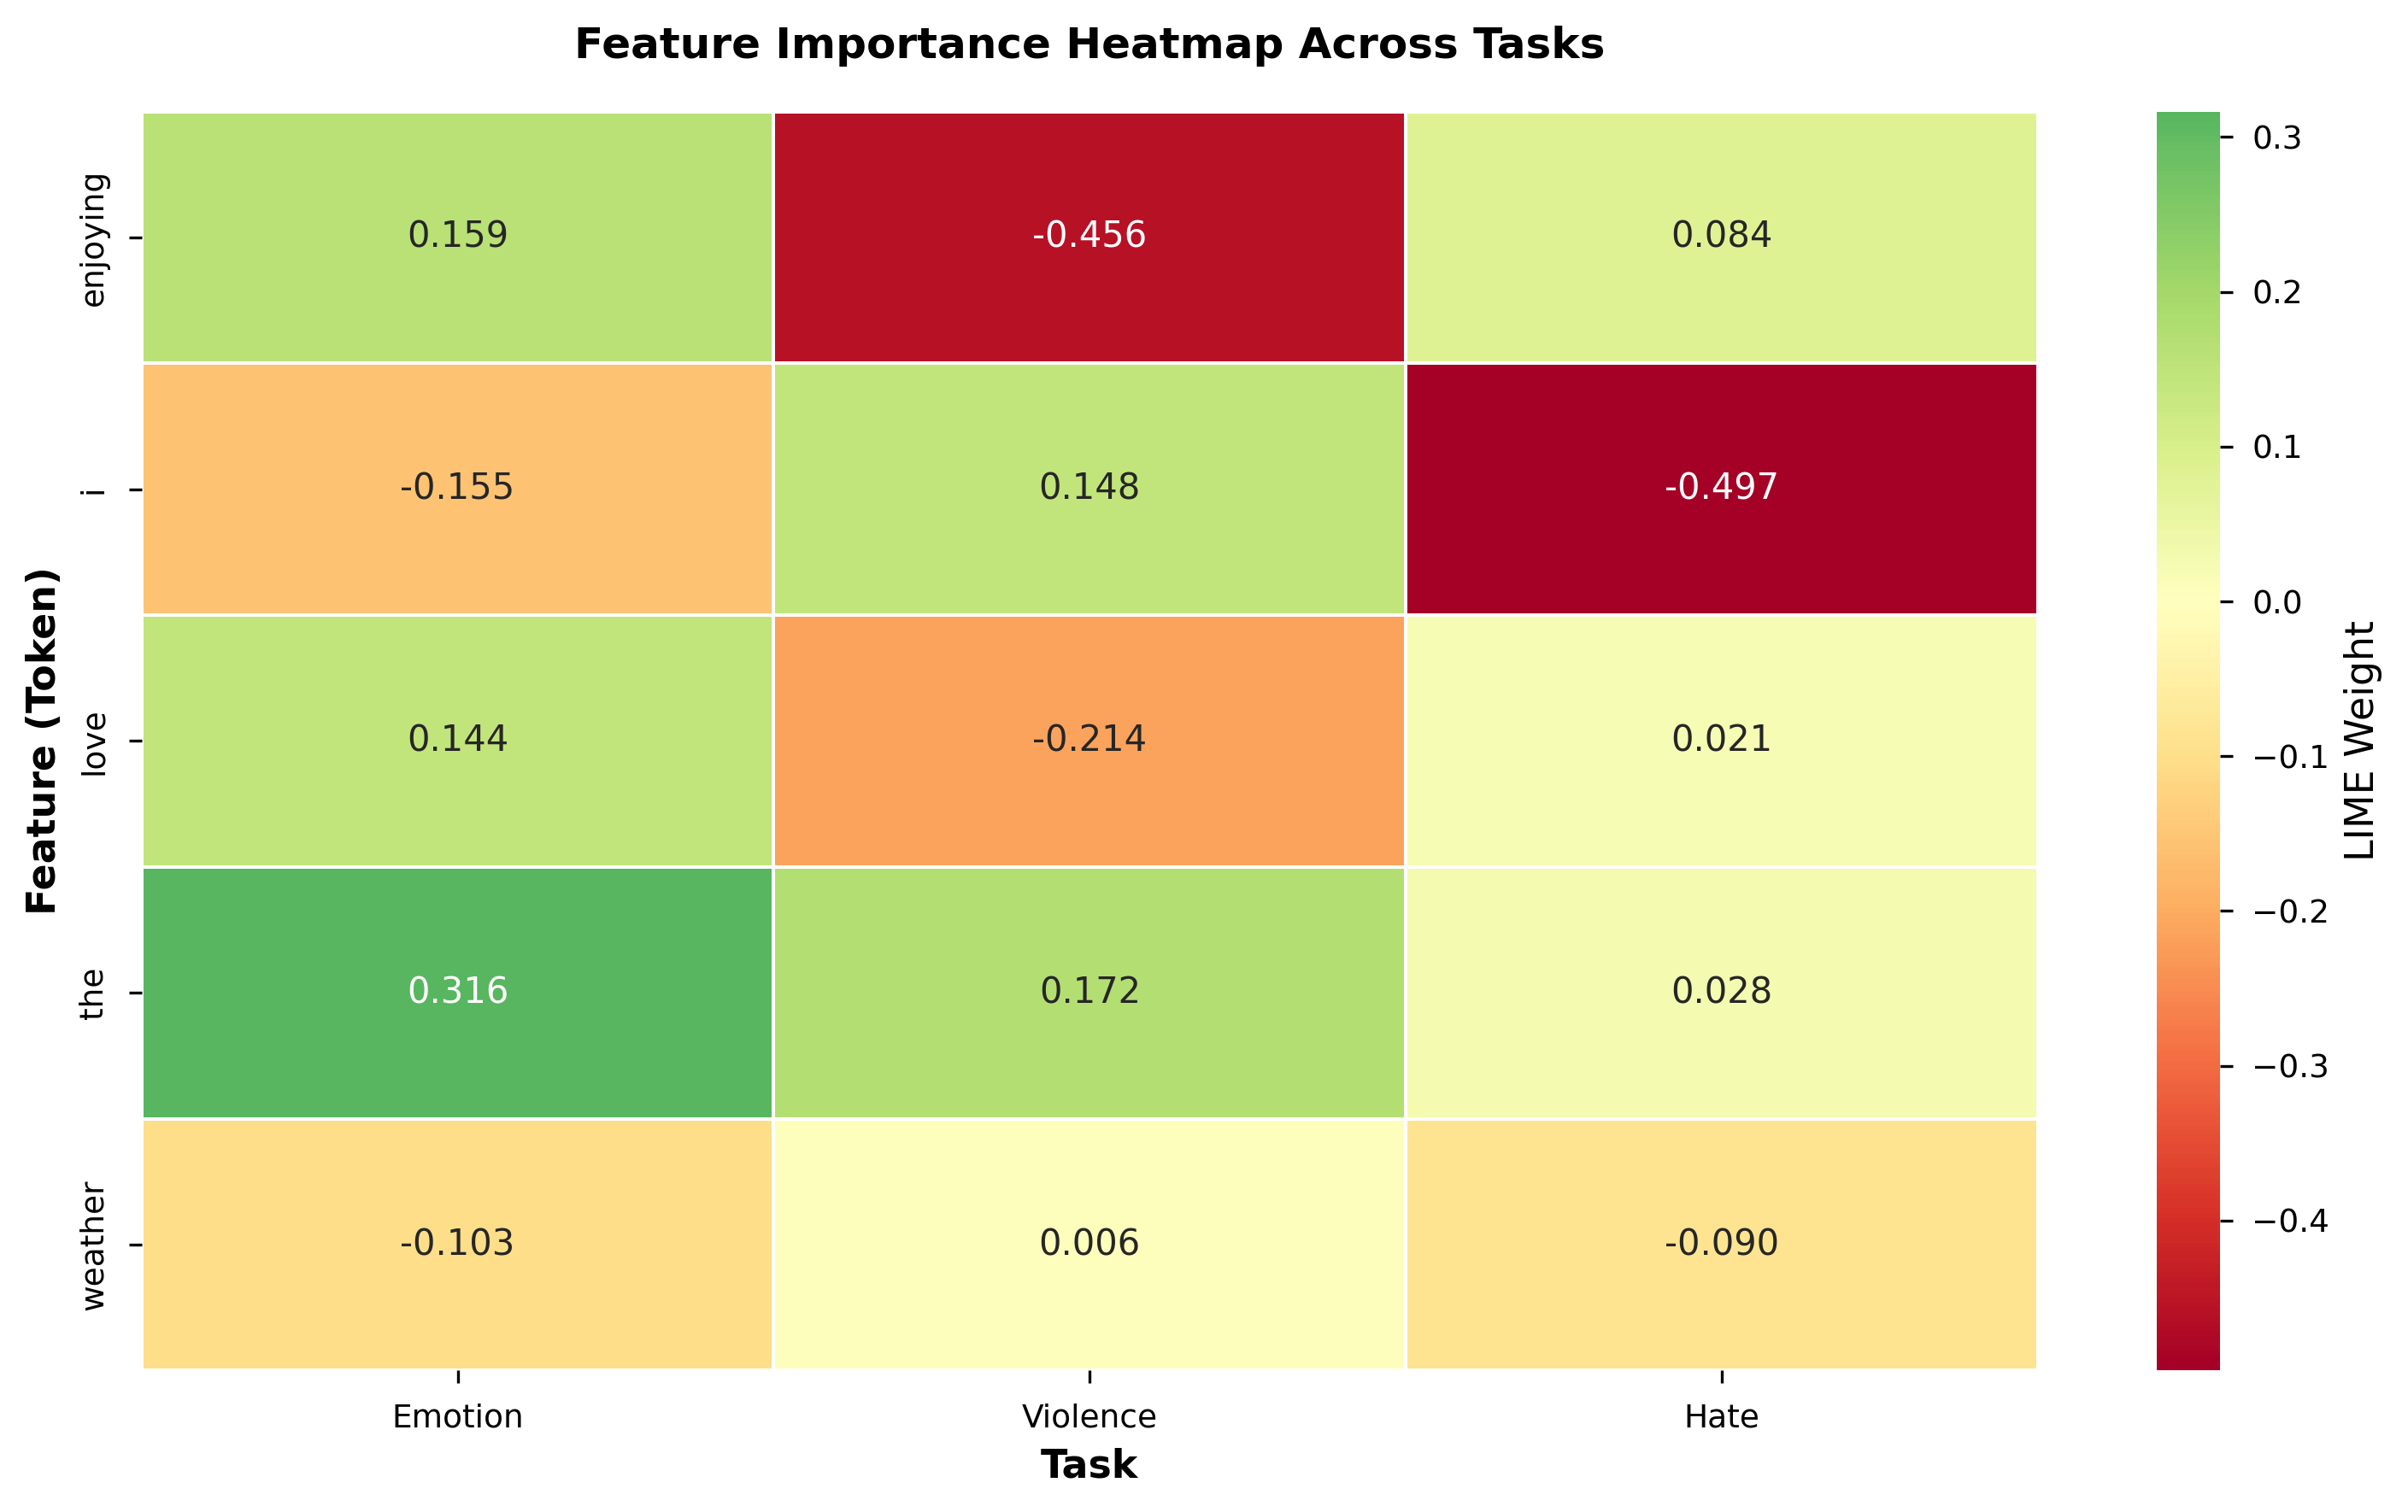

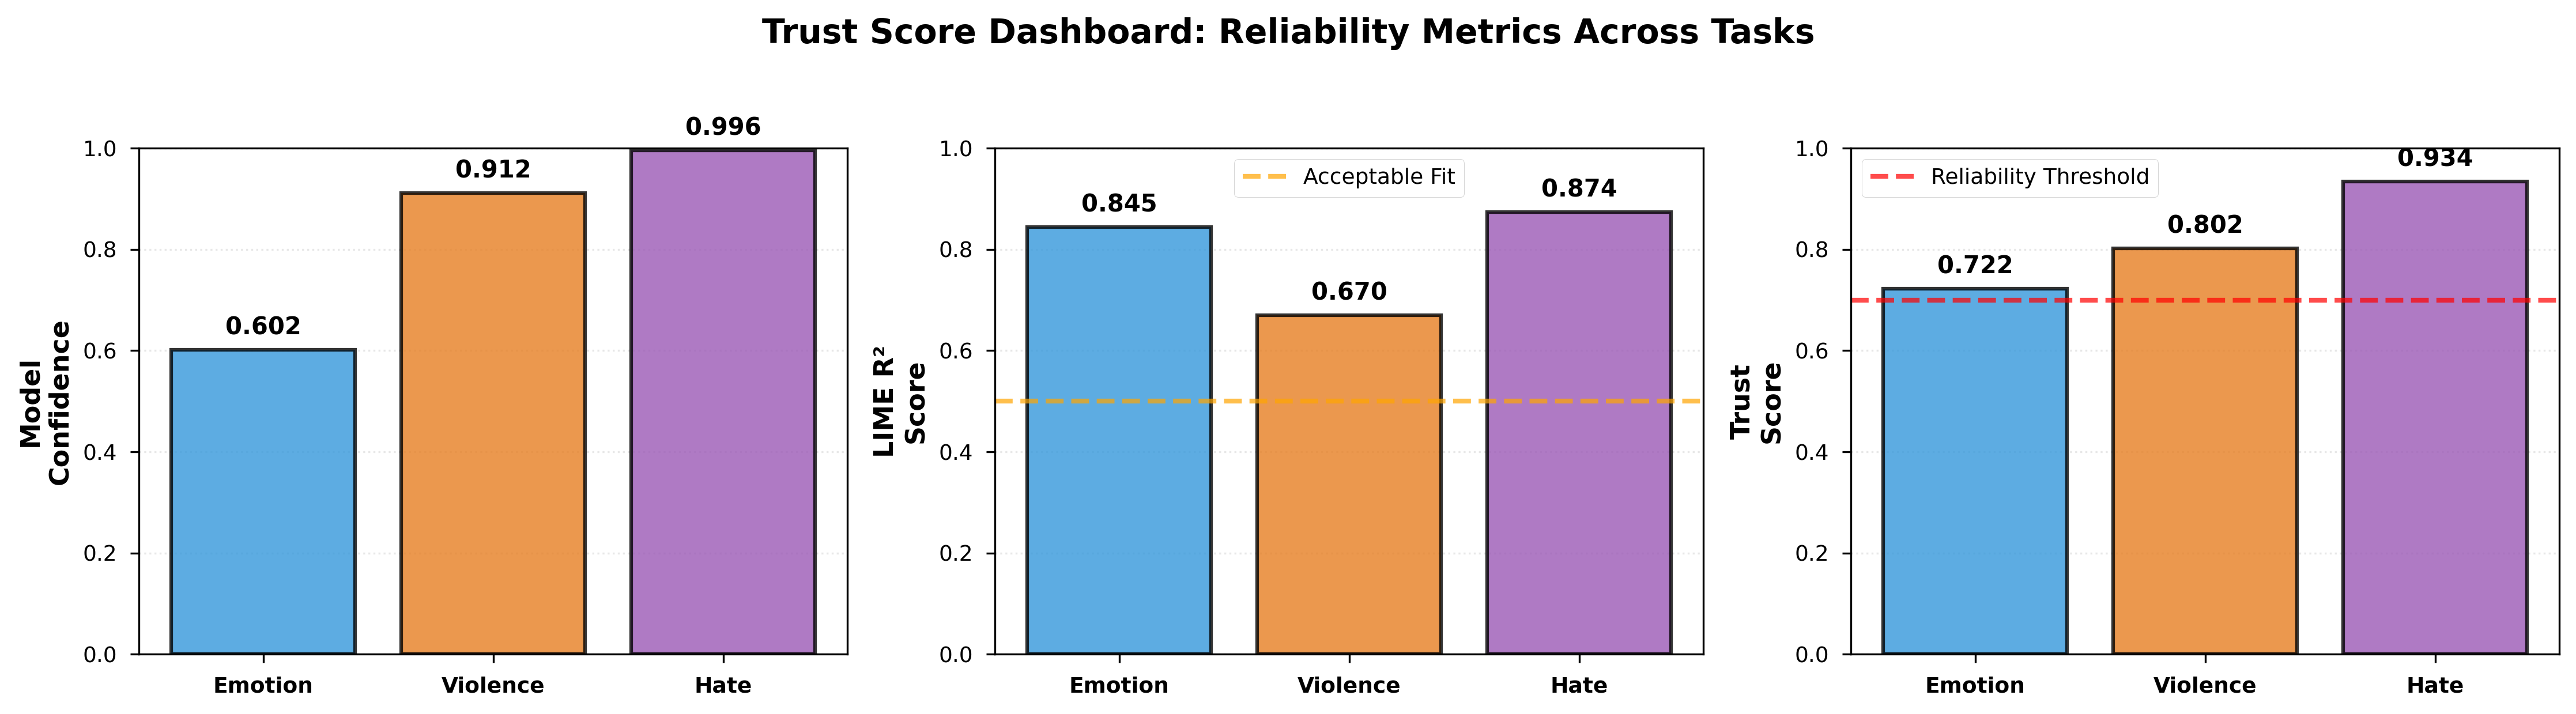

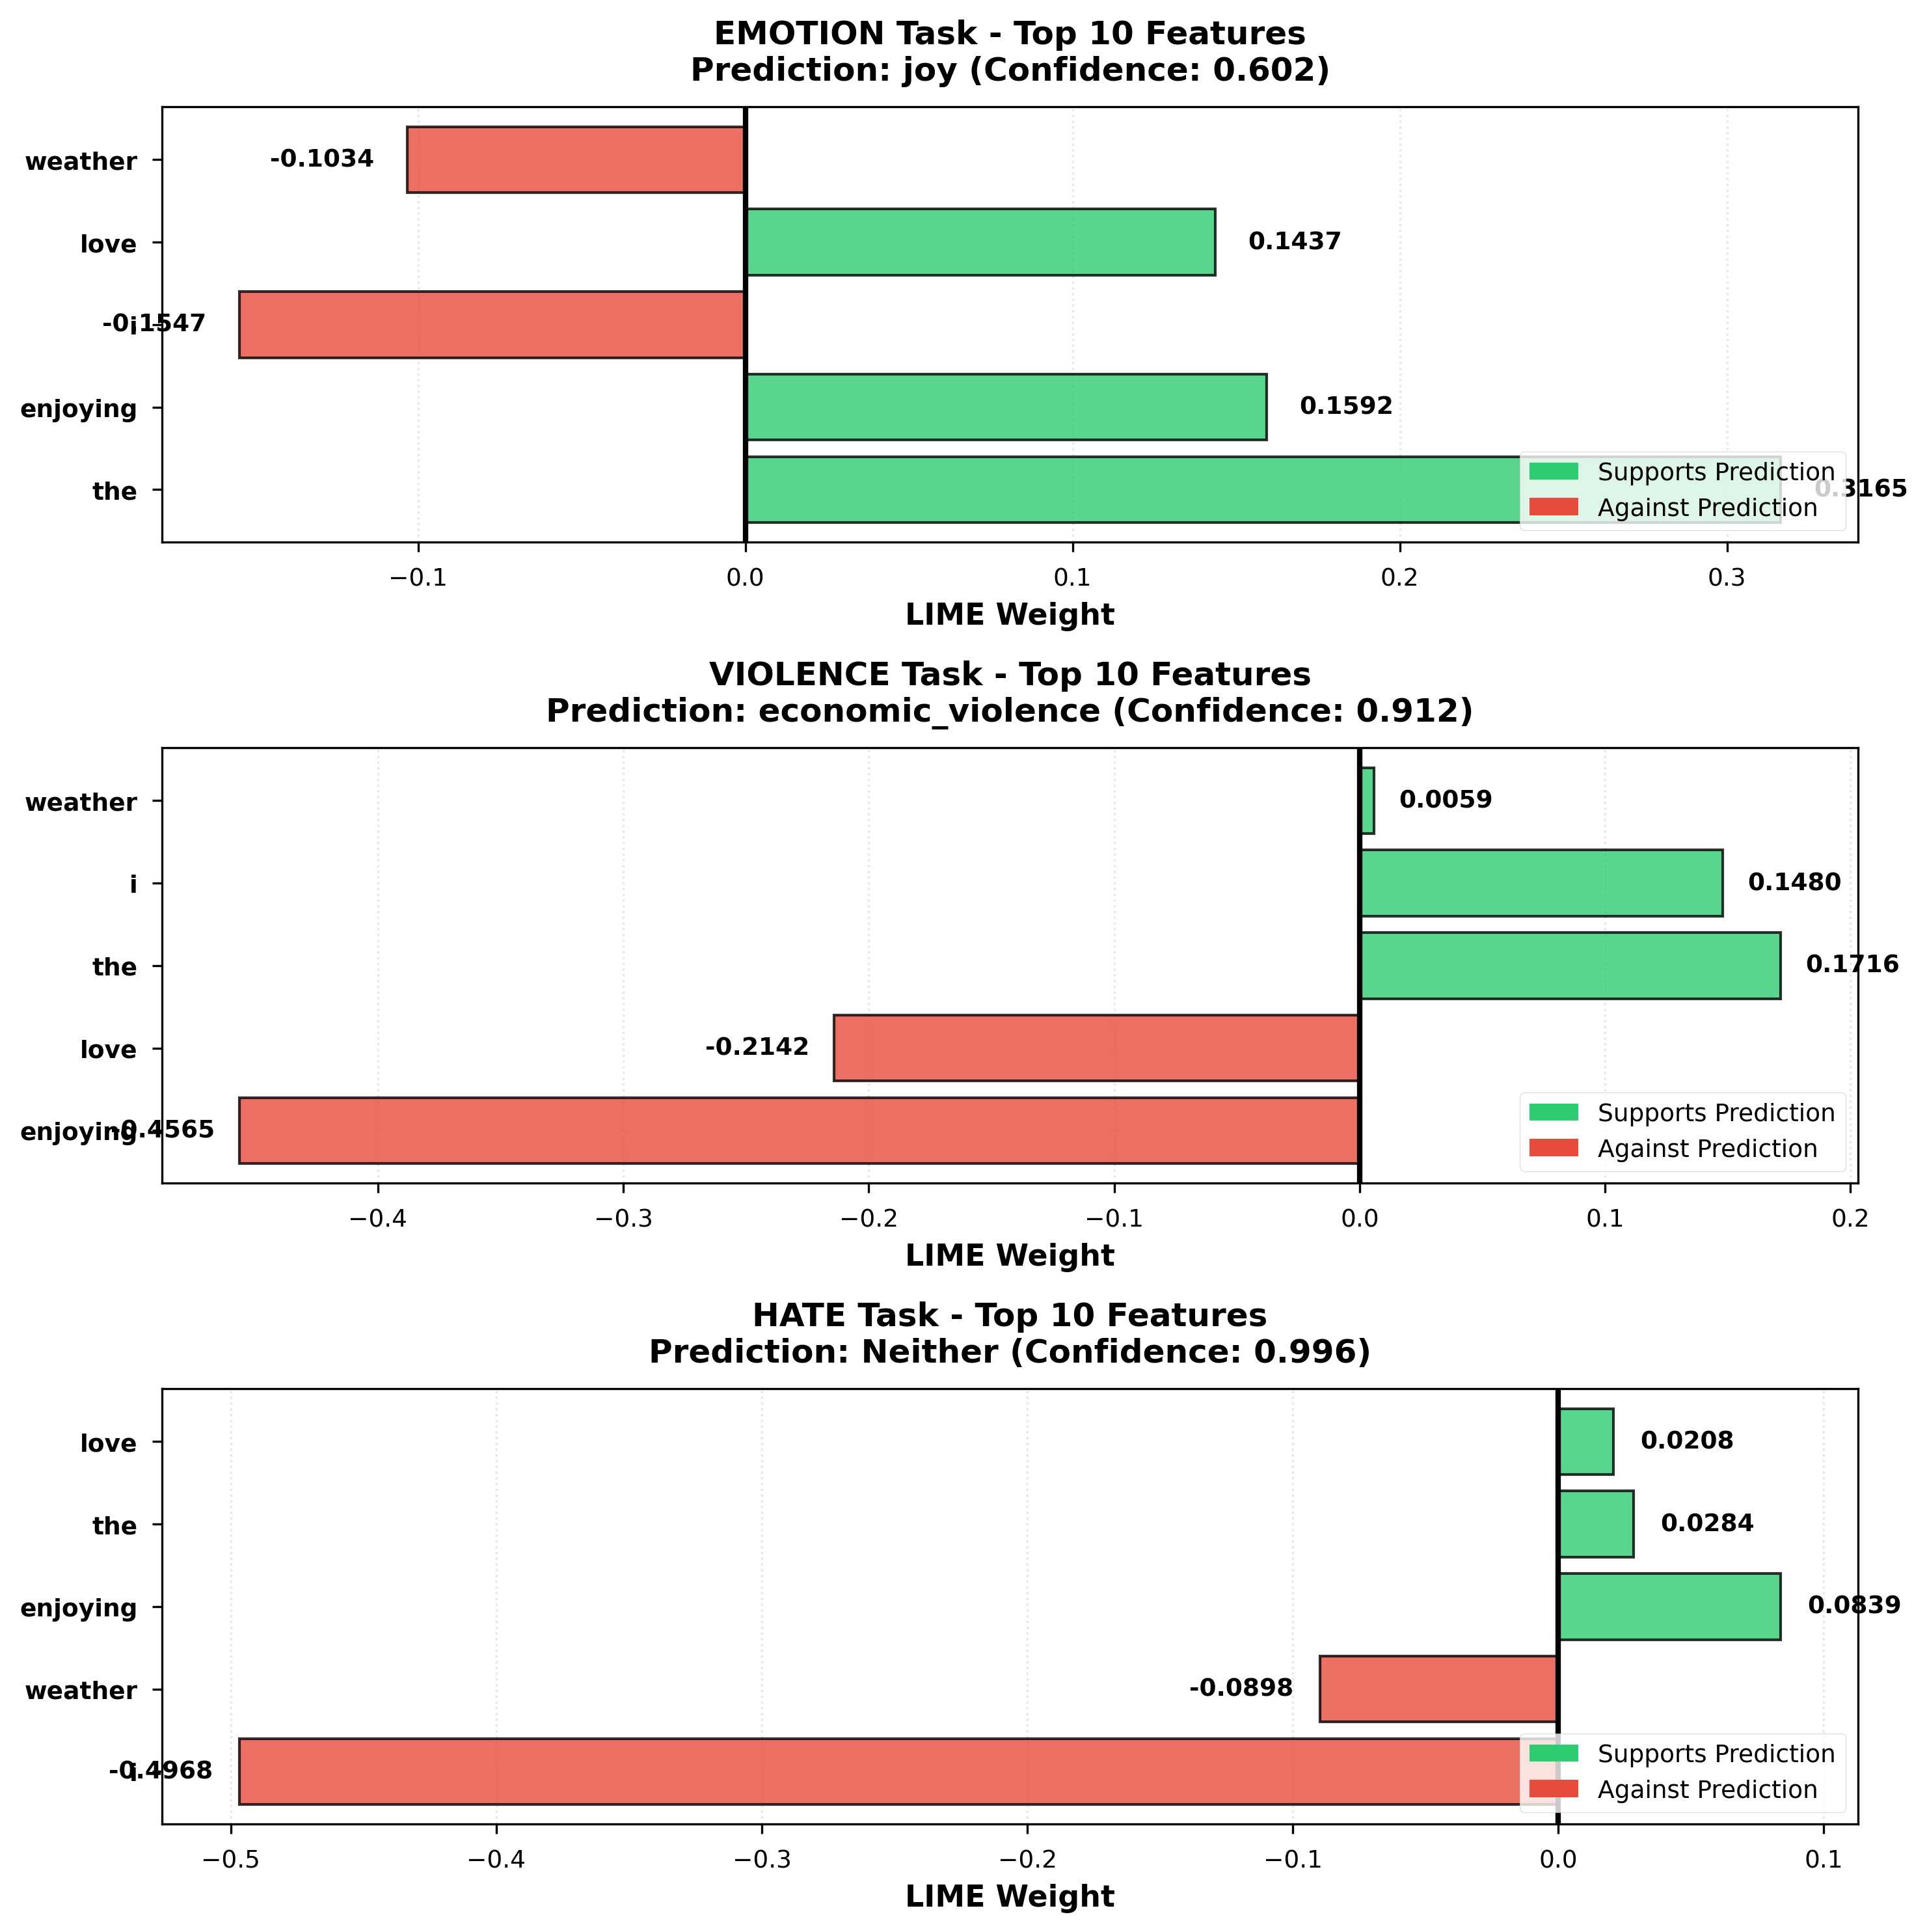

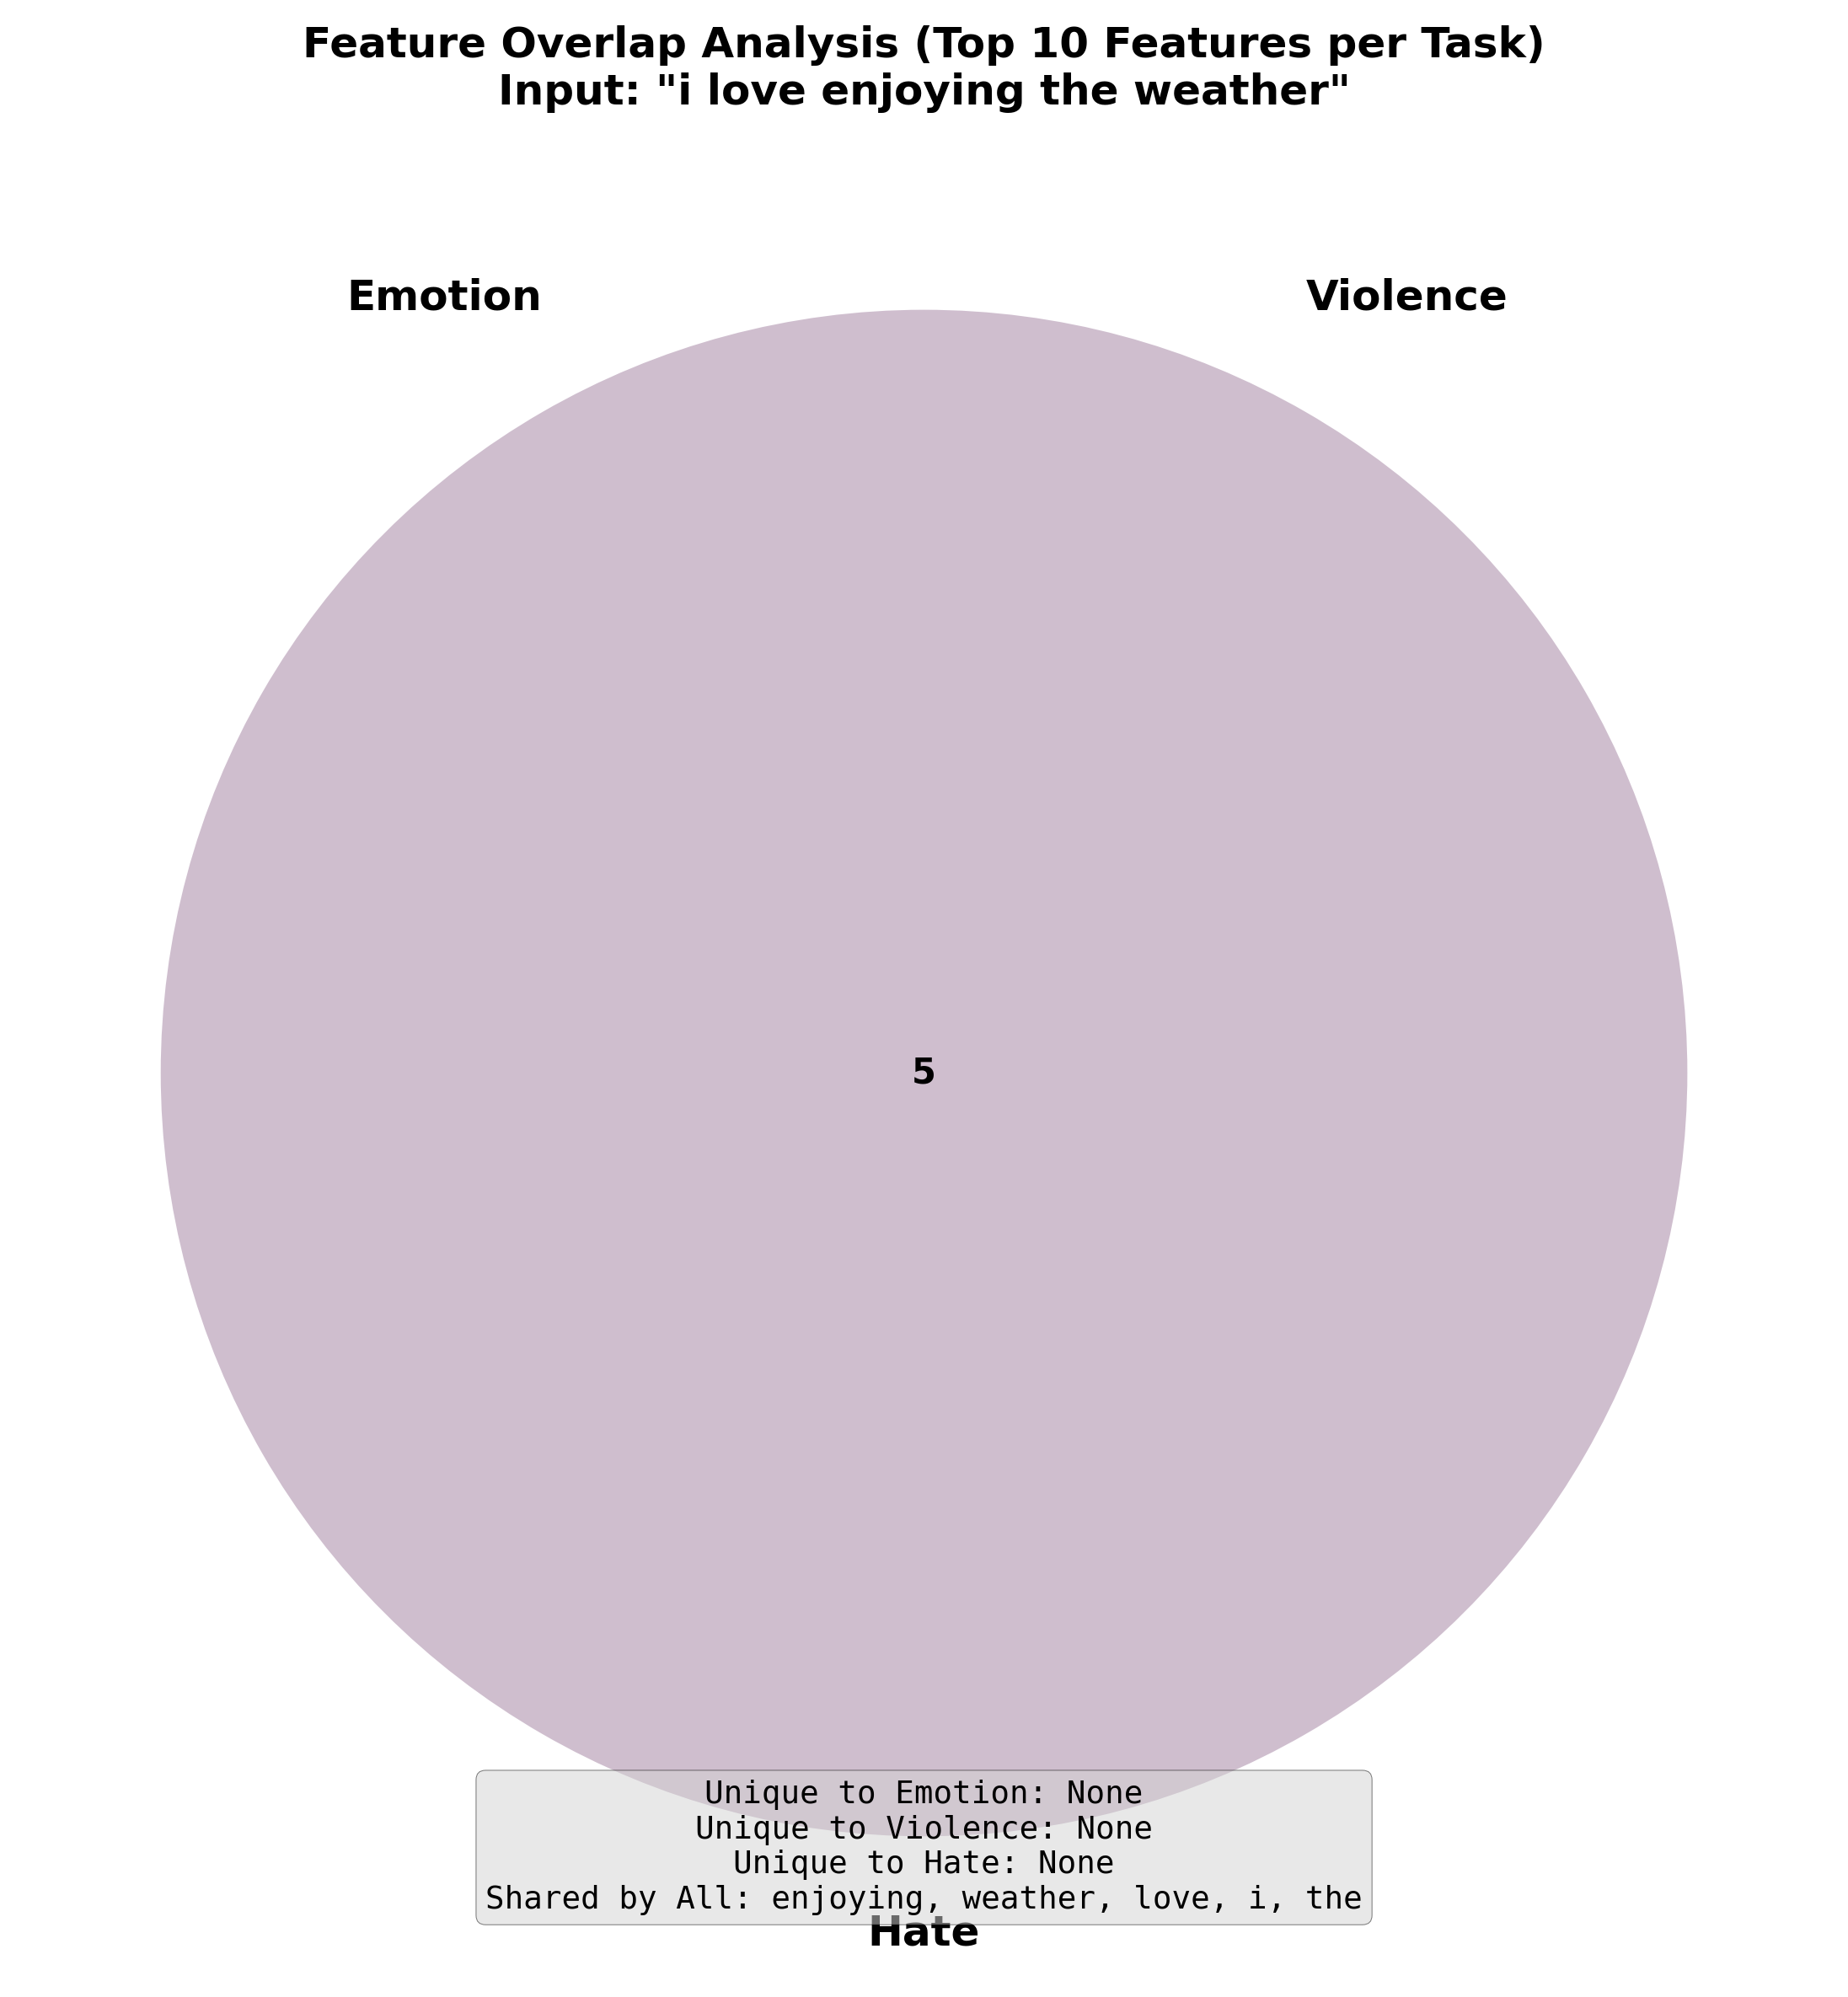

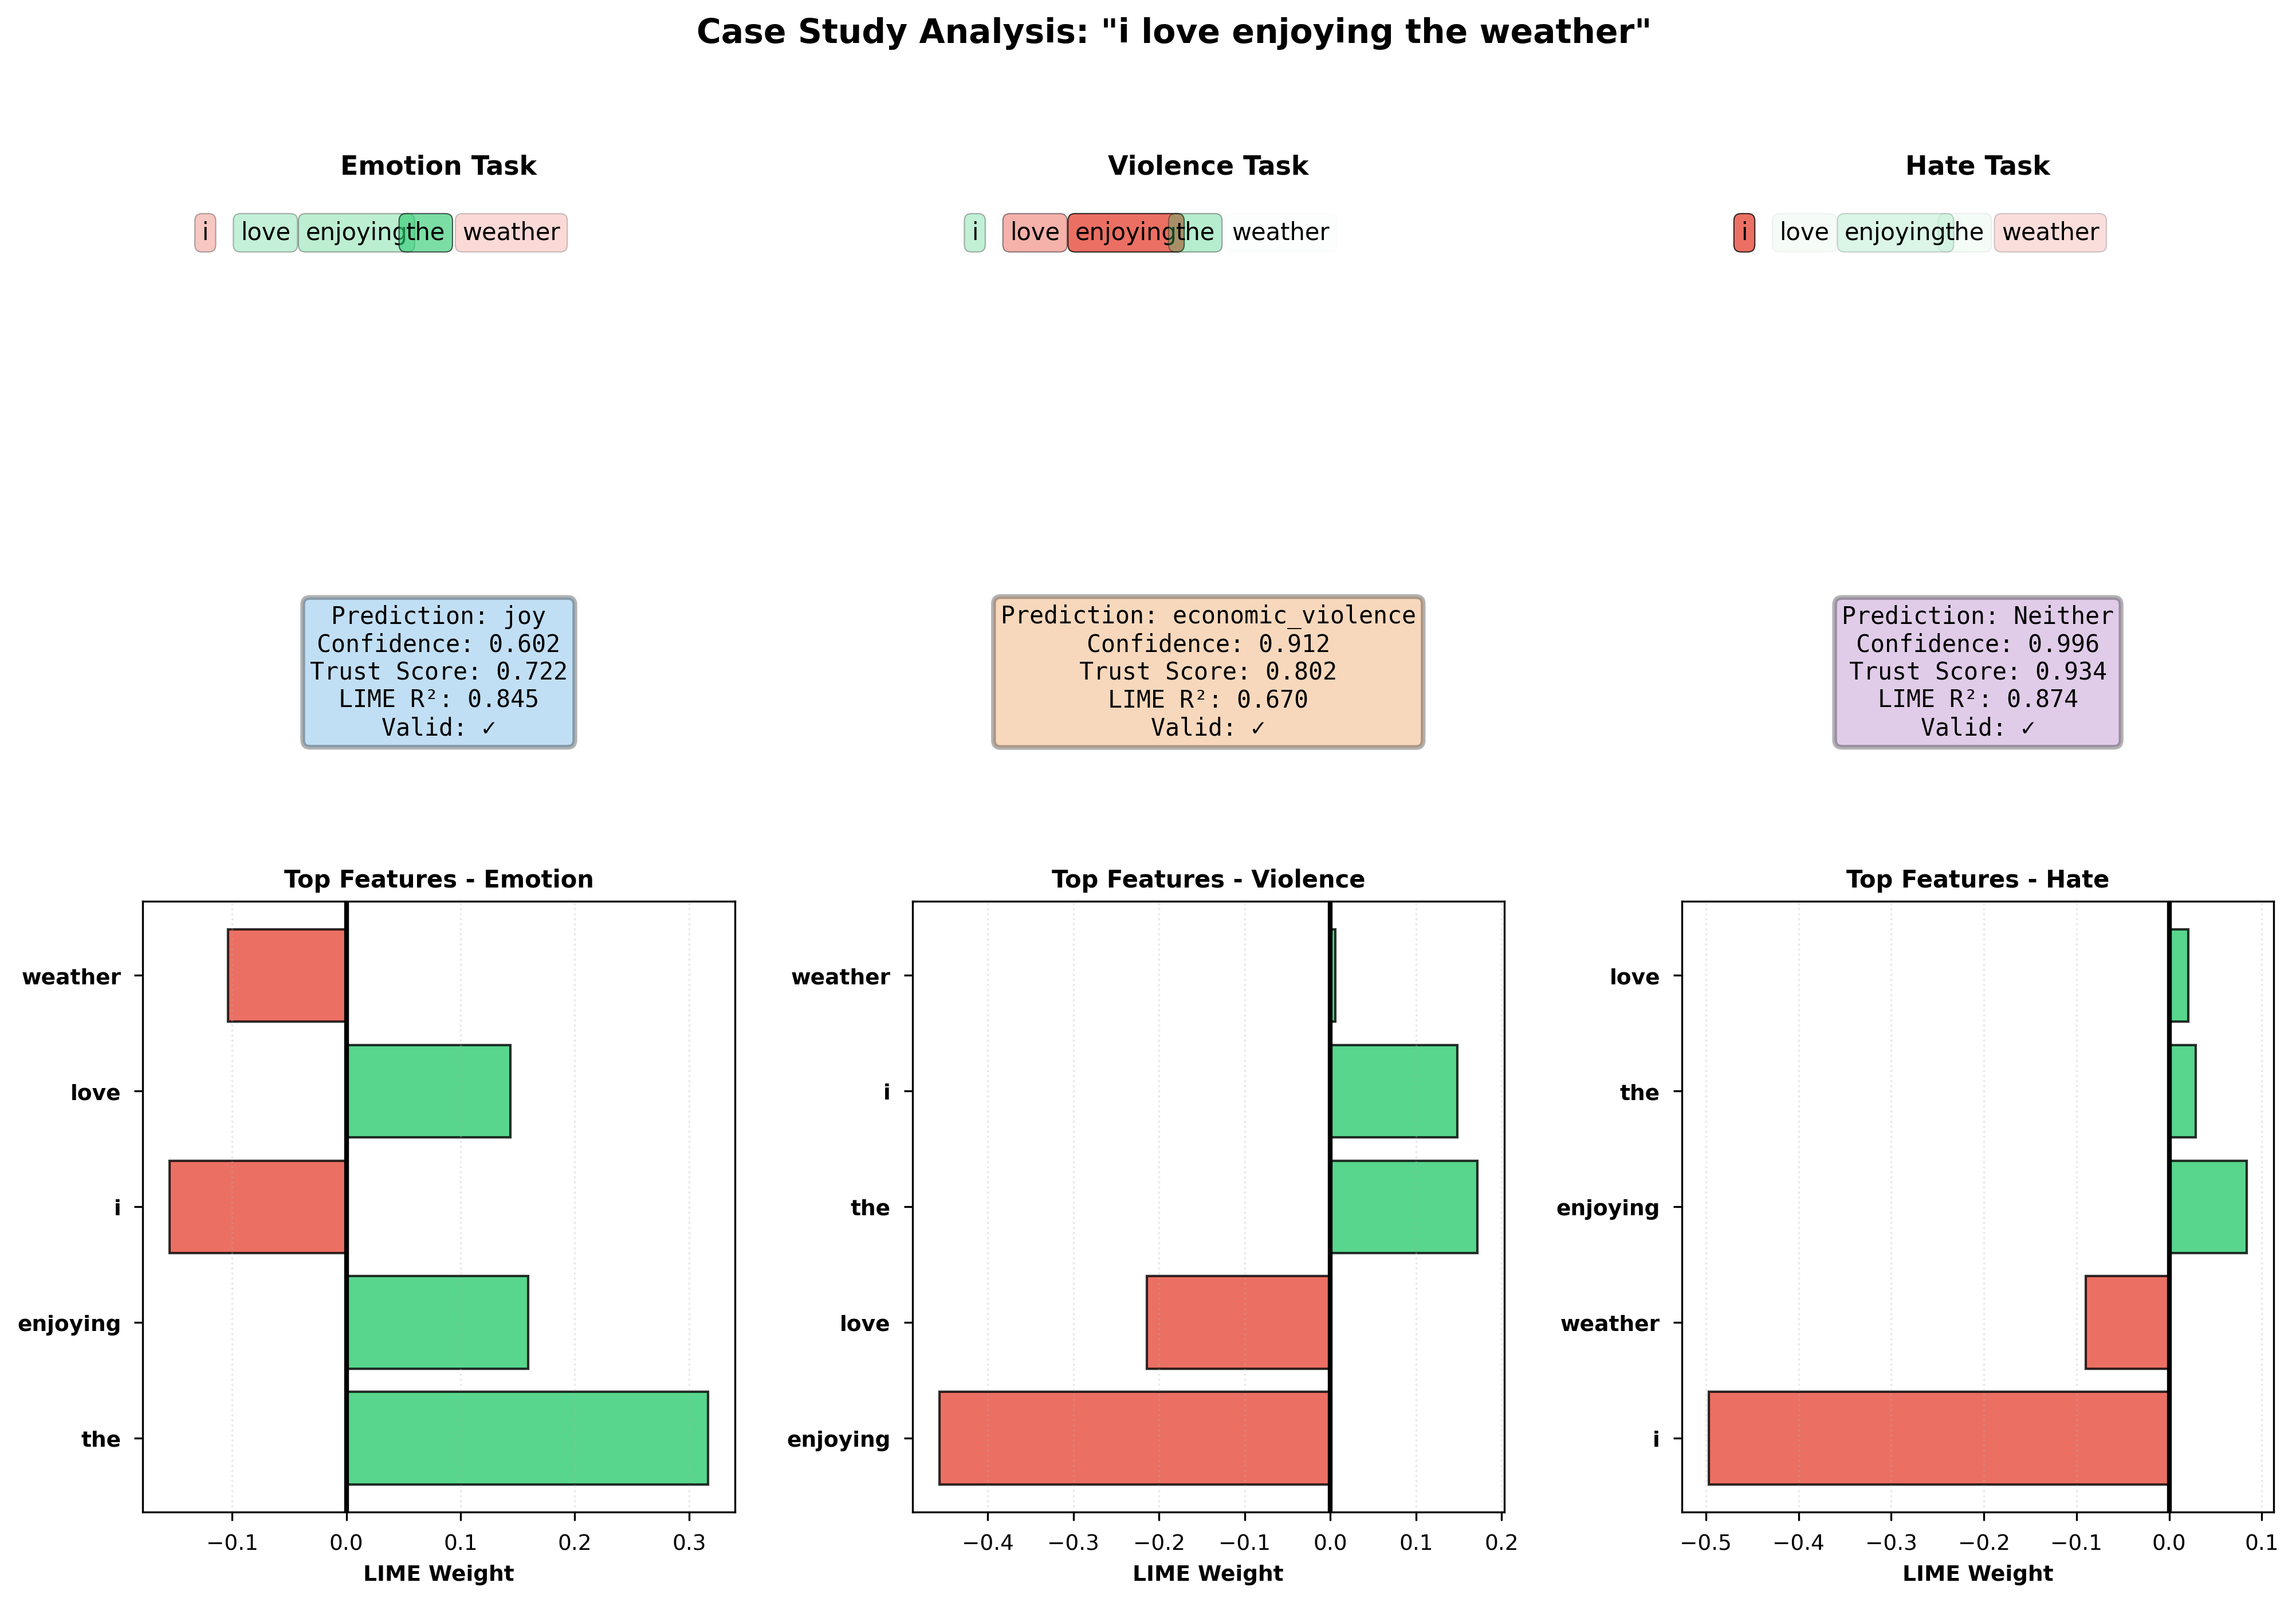

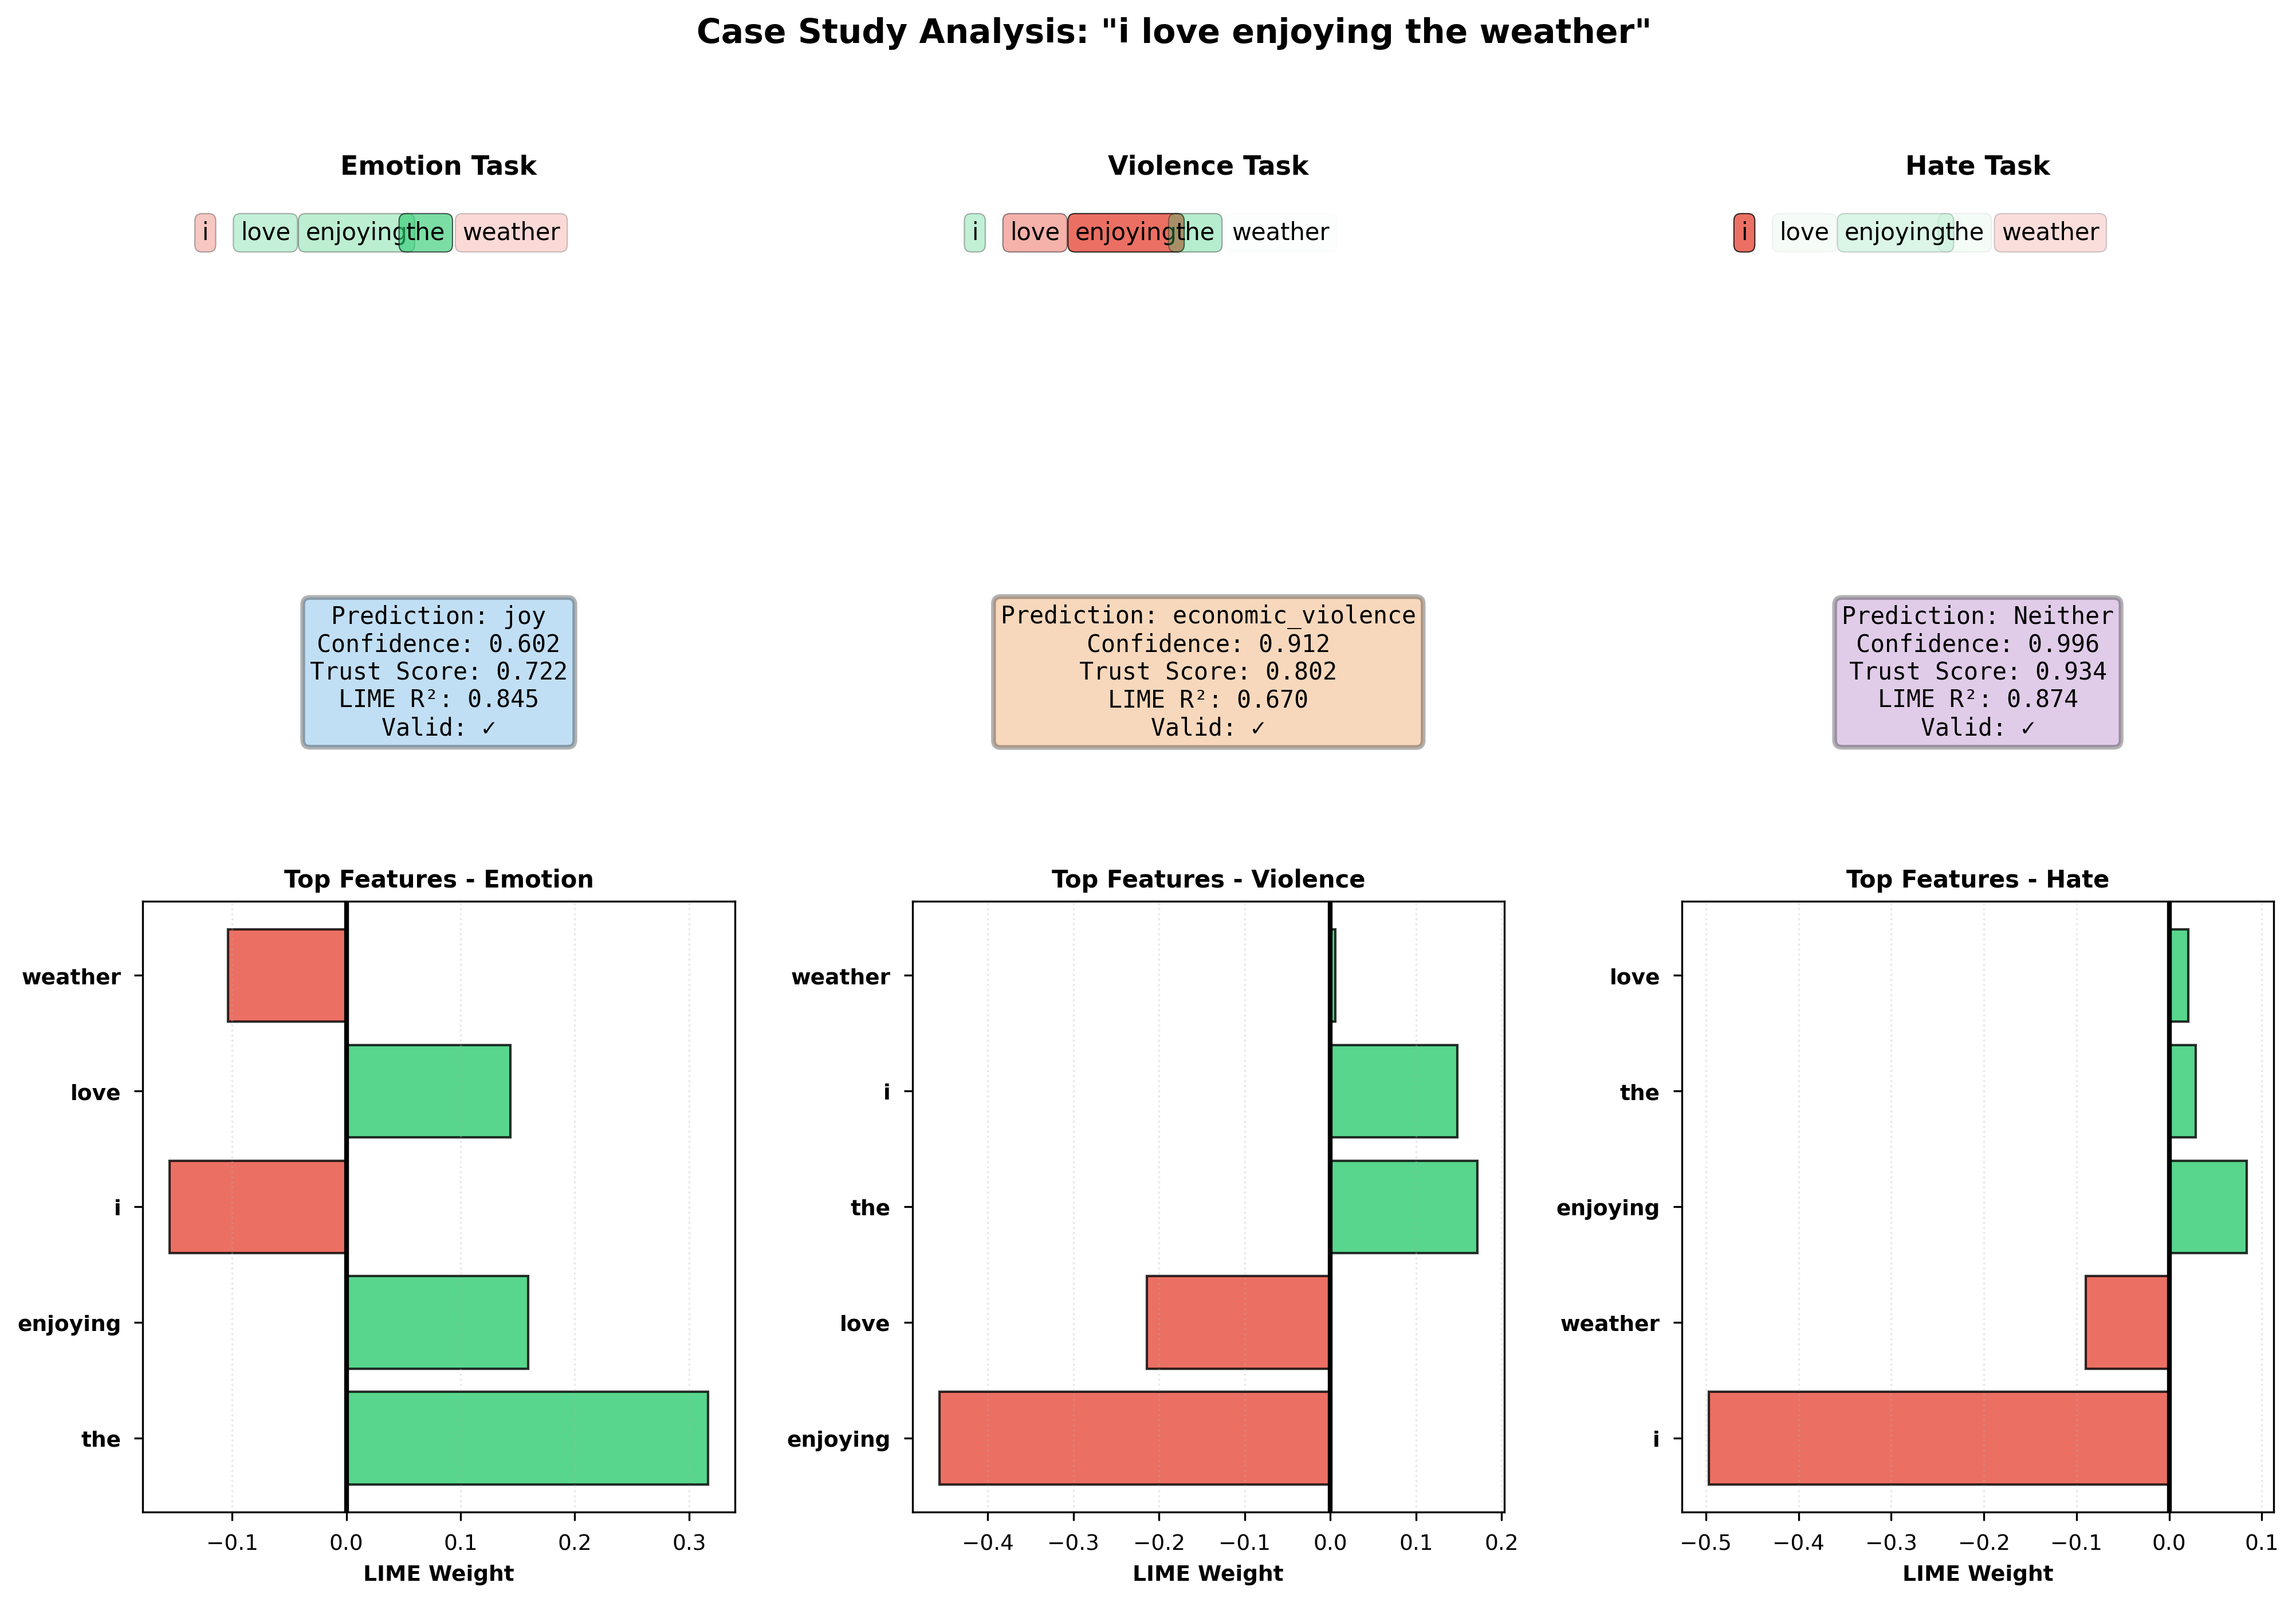

In [44]:
# =============================================================================
# STREAMLINED LIME VISUALIZATION MODULE (ESSENTIAL PLOTS ONLY)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Patch
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set publication-ready style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9


# =============================================================================
# STREAMLINED VISUALIZER (5 ESSENTIAL PLOTS)
# =============================================================================
class LIMEVisualizer:
    def __init__(self, figsize_scale=1.0):
        self.figsize_scale = figsize_scale
        self.colors = {
            'positive': '#2ecc71',
            'negative': '#e74c3c',
            'emotion': '#3498db',
            'violence': '#e67e22',
            'hate': '#9b59b6'
        }
    
    # =========================================================================
    # VIZ 1: FEATURE IMPORTANCE HEATMAP
    # =========================================================================
    def plot_feature_heatmap(self, result, top_k=10):
        """Feature importance heatmap across all tasks"""
        fig, ax = plt.subplots(figsize=(10*self.figsize_scale, 6*self.figsize_scale))
        
        tasks = ['emotion', 'violence', 'hate']
        all_features = set()
        
        for task in tasks:
            features = [tok for tok, _ in result[task]['explanation'][:top_k]]
            all_features.update(features)
        
        feature_list = sorted(list(all_features))
        weight_matrix = np.zeros((len(feature_list), len(tasks)))
        
        for j, task in enumerate(tasks):
            feature_weights = dict(result[task]['explanation'])
            for i, feature in enumerate(feature_list):
                weight_matrix[i, j] = feature_weights.get(feature, 0)
        
        sns.heatmap(weight_matrix, 
                    xticklabels=[t.capitalize() for t in tasks],
                    yticklabels=feature_list,
                    cmap='RdYlGn',
                    center=0,
                    annot=True,
                    fmt='.3f',
                    cbar_kws={'label': 'LIME Weight'},
                    ax=ax,
                    linewidths=0.5)
        
        ax.set_title('Feature Importance Heatmap Across Tasks', fontweight='bold', pad=15)
        ax.set_xlabel('Task', fontweight='bold')
        ax.set_ylabel('Feature (Token)', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # =========================================================================
    # VIZ 2: TRUST SCORE DASHBOARD
    # =========================================================================
    def plot_trust_dashboard(self, result):
        """Comprehensive trust metrics comparison"""
        fig, axes = plt.subplots(1, 3, figsize=(15*self.figsize_scale, 4*self.figsize_scale))
        
        tasks = ['emotion', 'violence', 'hate']
        metrics = ['confidence', 'lime_r2_score', 'trust_score']
        metric_labels = ['Model\nConfidence', 'LIME R²\nScore', 'Trust\nScore']
        colors_list = [self.colors['emotion'], self.colors['violence'], self.colors['hate']]
        
        for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
            ax = axes[idx]
            values = [result[task][metric] for task in tasks]
            
            bars = ax.bar(tasks, values, color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)
            
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
            
            if metric == 'trust_score':
                ax.axhline(y=0.7, color='red', linestyle='--', linewidth=2, 
                          label='Reliability Threshold', alpha=0.7)
                ax.legend()
            elif metric == 'lime_r2_score':
                ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=2,
                          label='Acceptable Fit', alpha=0.7)
                ax.legend()
            
            ax.set_ylabel(label, fontweight='bold')
            ax.set_ylim([0, 1.0])
            ax.set_xticklabels([t.capitalize() for t in tasks], fontweight='bold')
            ax.grid(axis='y', alpha=0.3, linestyle=':')
            ax.set_axisbelow(True)
        
        fig.suptitle('Trust Score Dashboard: Reliability Metrics Across Tasks', 
                     fontsize=14, fontweight='bold', y=1.02)
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # =========================================================================
    # VIZ 3: LIME WEIGHT DISTRIBUTION
    # =========================================================================
    def plot_lime_weights(self, result, top_k=10):
        """Horizontal bar charts showing LIME feature weights"""
        fig, axes = plt.subplots(3, 1, figsize=(10*self.figsize_scale, 10*self.figsize_scale))
        
        tasks = ['emotion', 'violence', 'hate']
        task_colors = [self.colors['emotion'], self.colors['violence'], self.colors['hate']]
        
        for idx, (task, task_color) in enumerate(zip(tasks, task_colors)):
            ax = axes[idx]
            
            features = result[task]['explanation'][:top_k]
            tokens = [tok for tok, _ in features]
            weights = [w for _, w in features]
            
            colors = [self.colors['positive'] if w > 0 else self.colors['negative'] for w in weights]
            
            y_pos = np.arange(len(tokens))
            bars = ax.barh(y_pos, weights, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
            
            for i, (bar, weight) in enumerate(zip(bars, weights)):
                x_pos = weight + (0.01 if weight > 0 else -0.01)
                ha = 'left' if weight > 0 else 'right'
                ax.text(x_pos, i, f'{weight:.4f}', va='center', ha=ha, fontweight='bold', fontsize=9)
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(tokens, fontweight='bold')
            ax.set_xlabel('LIME Weight', fontweight='bold')
            ax.set_title(f'{task.upper()} Task - Top {top_k} Features\n'
                        f'Prediction: {result[task]["prediction"]} '
                        f'(Confidence: {result[task]["confidence"]:.3f})',
                        fontweight='bold', pad=10)
            ax.axvline(x=0, color='black', linewidth=2, linestyle='-')
            ax.grid(axis='x', alpha=0.3, linestyle=':')
            ax.set_axisbelow(True)
            
            legend_elements = [
                Patch(facecolor=self.colors['positive'], label='Supports Prediction'),
                Patch(facecolor=self.colors['negative'], label='Against Prediction')
            ]
            ax.legend(handles=legend_elements, loc='lower right')
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # =========================================================================
    # VIZ 4: FEATURE OVERLAP ANALYSIS
    # =========================================================================
    def plot_feature_overlap(self, result, top_k=10):
        """Venn diagram showing shared vs unique features across tasks"""
        from matplotlib_venn import venn3
        
        fig, ax = plt.subplots(figsize=(10*self.figsize_scale, 8*self.figsize_scale))
        
        emo_features = set([tok for tok, _ in result['emotion']['explanation'][:top_k]])
        vio_features = set([tok for tok, _ in result['violence']['explanation'][:top_k]])
        hate_features = set([tok for tok, _ in result['hate']['explanation'][:top_k]])
        
        venn = venn3([emo_features, vio_features, hate_features],
                    set_labels=('Emotion', 'Violence', 'Hate'),
                    set_colors=(self.colors['emotion'], self.colors['violence'], 
                               self.colors['hate']),
                    alpha=0.6, ax=ax)
        
        for text in venn.set_labels:
            if text:
                text.set_fontweight('bold')
                text.set_fontsize(12)
        
        for text in venn.subset_labels:
            if text:
                text.set_fontweight('bold')
                text.set_fontsize(10)
        
        ax.set_title(f'Feature Overlap Analysis (Top {top_k} Features per Task)\n'
                    f'Input: "{result["input_text"]}"',
                    fontweight='bold', fontsize=12, pad=20)
        
        fig.text(0.5, 0.05, 
                f'Unique to Emotion: {", ".join(emo_features - vio_features - hate_features) if emo_features - vio_features - hate_features else "None"}\n'
                f'Unique to Violence: {", ".join(vio_features - emo_features - hate_features) if vio_features - emo_features - hate_features else "None"}\n'
                f'Unique to Hate: {", ".join(hate_features - emo_features - vio_features) if hate_features - emo_features - vio_features else "None"}\n'
                f'Shared by All: {", ".join(emo_features & vio_features & hate_features) if emo_features & vio_features & hate_features else "None"}',
                ha='center', fontsize=9, family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # =========================================================================
    # VIZ 5: CASE STUDY DEEP DIVE
    # =========================================================================
    def plot_case_study(self, result):
        """Comprehensive single-case analysis with highlighted text"""
        fig = plt.figure(figsize=(16*self.figsize_scale, 10*self.figsize_scale))
        gs = GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.3)
        
        text = result['input_text']
        
        fig.suptitle(f'Case Study Analysis: "{text}"', fontsize=14, fontweight='bold', y=0.98)
        
        tasks = ['emotion', 'violence', 'hate']
        
        # Top row: Text highlighting
        for idx, task in enumerate(tasks):
            ax = fig.add_subplot(gs[0, idx])
            ax.axis('off')
            
            feature_weights = dict(result[task]['explanation'][:5])
            words = text.split()
            highlighted = []
            
            for word in words:
                word_lower = word.lower().strip('.,!?')
                if word_lower in feature_weights:
                    weight = feature_weights[word_lower]
                    color = self.colors['positive'] if weight > 0 else self.colors['negative']
                    alpha = min(abs(weight) * 2, 0.8)
                    highlighted.append((word, color, alpha))
                else:
                    highlighted.append((word, 'white', 0))
            
            y_pos = 0.8
            x_pos = 0.1
            for word, color, alpha in highlighted:
                bbox = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=alpha, 
                           edgecolor='black', linewidth=0.5)
                ax.text(x_pos, y_pos, word, fontsize=10, bbox=bbox, transform=ax.transAxes)
                x_pos += len(word) * 0.015 + 0.05
                if x_pos > 0.85:
                    x_pos = 0.1
                    y_pos -= 0.15
            
            ax.set_title(f'{task.capitalize()} Task', fontweight='bold', fontsize=11)
        
        # Second row: Prediction info
        for idx, task in enumerate(tasks):
            ax = fig.add_subplot(gs[1, idx])
            ax.axis('off')
            
            info_text = (
                f"Prediction: {result[task]['prediction']}\n"
                f"Confidence: {result[task]['confidence']:.3f}\n"
                f"Trust Score: {result[task]['trust_score']:.3f}\n"
                f"LIME R²: {result[task]['lime_r2_score']:.3f}\n"
                f"Valid: {'✓' if result[task]['validation']['is_valid'] else '✗'}"
            )
            
            color_map = {'emotion': self.colors['emotion'], 
                        'violence': self.colors['violence'],
                        'hate': self.colors['hate']}
            
            ax.text(0.5, 0.5, info_text, transform=ax.transAxes,
                   fontsize=10, ha='center', va='center', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor=color_map[task], 
                            alpha=0.3, edgecolor='black', linewidth=2))
        
        # Bottom rows: Top features bar charts
        for idx, task in enumerate(tasks):
            ax = fig.add_subplot(gs[2:, idx])
            
            features = result[task]['explanation'][:8]
            tokens = [tok for tok, _ in features]
            weights = [w for _, w in features]
            
            colors = [self.colors['positive'] if w > 0 else self.colors['negative'] for w in weights]
            
            y_pos = np.arange(len(tokens))
            ax.barh(y_pos, weights, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(tokens, fontsize=9, fontweight='bold')
            ax.set_xlabel('LIME Weight', fontweight='bold', fontsize=9)
            ax.set_title(f'Top Features - {task.capitalize()}', fontweight='bold', fontsize=10)
            ax.axvline(x=0, color='black', linewidth=2)
            ax.grid(axis='x', alpha=0.3, linestyle=':')
        
        plt.tight_layout()
        plt.show()
        return fig
    
    # =========================================================================
    # GENERATE ALL 5 VISUALIZATIONS
    # =========================================================================
    def generate_all(self, result):
        """Generate all 5 essential visualizations"""
        print("Generating visualizations...")
        
        print("1/5 - Feature Heatmap")
        self.plot_feature_heatmap(result)
        
        print("2/5 - Trust Dashboard")
        self.plot_trust_dashboard(result)
        
        print("3/5 - LIME Weights")
        self.plot_lime_weights(result)
        
        print("4/5 - Feature Overlap")
        self.plot_feature_overlap(result)
        
        print("5/5 - Case Study")
        self.plot_case_study(result)
        
        print("\n✓ All visualizations displayed!")


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

# Create visualizer
viz = LIMEVisualizer()

# Generate explanation
result = explainer.explain("i love enjoying the weather", num_samples=1000)

# Display all 5 visualizations
#viz.generate_all(result)

# OR display individually
viz.plot_feature_heatmap(result)
viz.plot_trust_dashboard(result)
viz.plot_lime_weights(result)
viz.plot_feature_overlap(result)
viz.plot_case_study(result)
